In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
orders = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Desktop\\projects\\FUTURE_DS_01\\data\\processed\\cleaned_df.csv",parse_dates = ["OrderDate"])

#### Revenue Trend

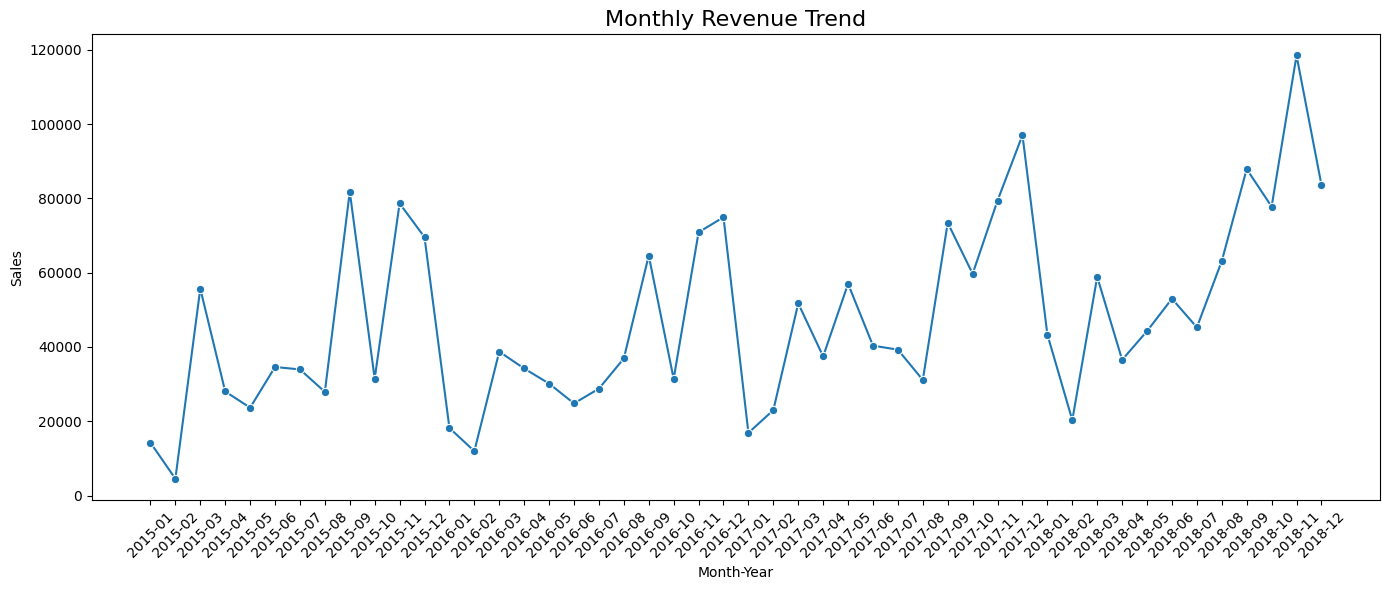

In [3]:
# Create Month-Year
orders["Month-Year"] = orders["OrderDate"].dt.to_period("M").astype(str)

monthly_sales = orders.groupby("Month-Year")["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x="Month-Year", y="Sales", marker="o")

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

#### Category Performance

In [4]:
# Category level analysis
category_analysis = orders.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

# Sort by Sales
category_analysis = category_analysis.sort_values(by="Sales", ascending=False)

category_analysis

,Category,Sales,Profit
2,Technology,834554.2730,145007.6618
0,Furniture,736598.3233,17271.4046
1,Office Supplies,716837.5220,121885.0358


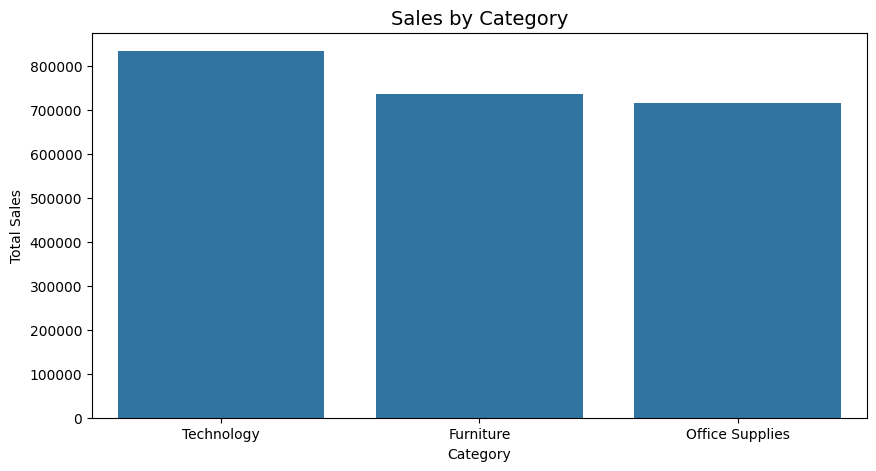

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(data=category_analysis, x="Category", y="Sales")

plt.title("Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

##### Profit Plot

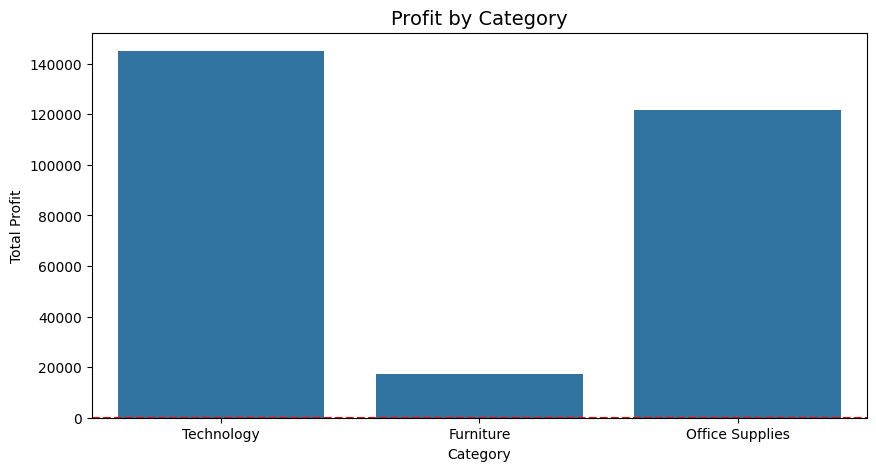

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(data=category_analysis, x="Category", y="Profit")

plt.title("Profit by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.axhline(0, color='red', linestyle='--')  # important line

plt.show()

#### Insights Found

Sales 
- Technology → Highest sales
- Furniture & Office Supplies → slightly lower but comparable

Profit
- Furniture category generates substantial revenue but contributes disproportionately low profit, indicating inefficiencies such as excessive discounting or high operational costs.



### Sub-Category Analysis

In [7]:
subcat_analysis = orders.groupby("SubCategory").agg({
    "Sales": "sum",
    "Profit": "sum"
})

# Sort by profit (important)
subcat_analysis = subcat_analysis.sort_values(by="Profit").reset_index()

subcat_analysis


,SubCategory,Sales,Profit
0,Tables,206965.5320,-17725.4811
1,Bookcases,110475.0963,-4485.6830
2,Supplies,46673.5380,-1189.0995
3,Fasteners,3024.2800,949.5182
4,Machines,189238.6310,3384.7569
5,Labels,12486.3120,5546.2540
6,Art,27110.7520,6525.0534
7,Envelopes,16474.3620,6963.2179
8,Furnishings,91705.1640,13059.1436
9,Appliances,106989.2210,17985.9822


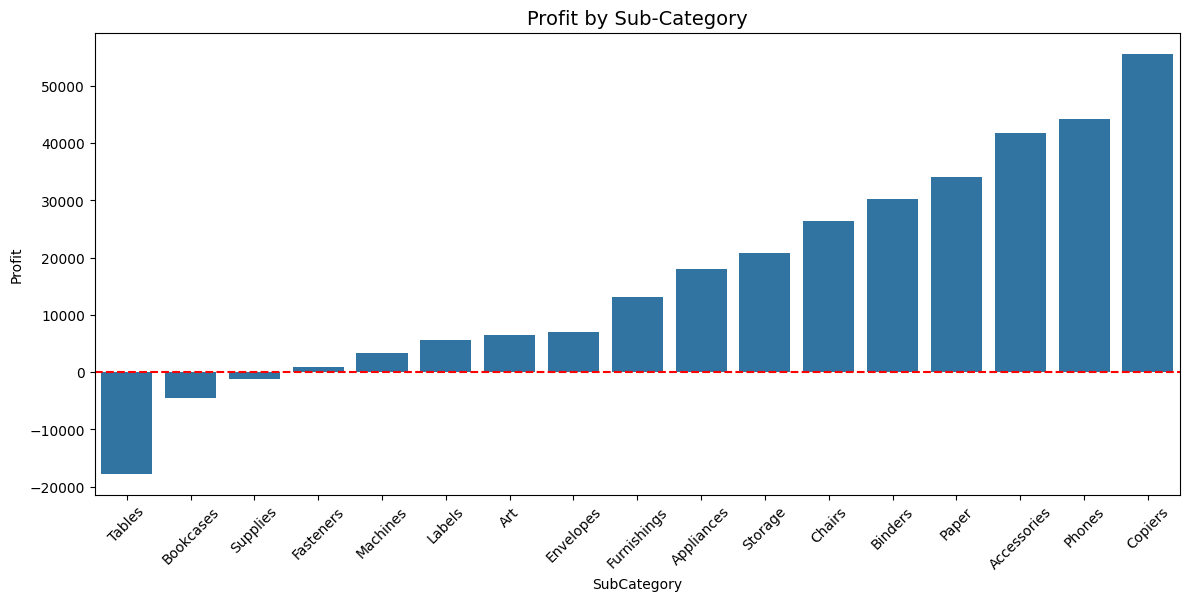

In [8]:
plt.figure(figsize=(14,6))

sns.barplot(data=subcat_analysis, x="SubCategory", y="Profit")

plt.xticks(rotation=45)
plt.title("Profit by Sub-Category", fontsize=14)

plt.axhline(0, color='red', linestyle='--')  # KEY LINE

plt.show()

#### Insight Found
Certain high-revenue sub-categories such as Tables are generating significant losses, indicating inefficient pricing or excessive discounting strategies

#### Profit vs Discount Analysis
Finding if Discounts are Destroying Profits

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


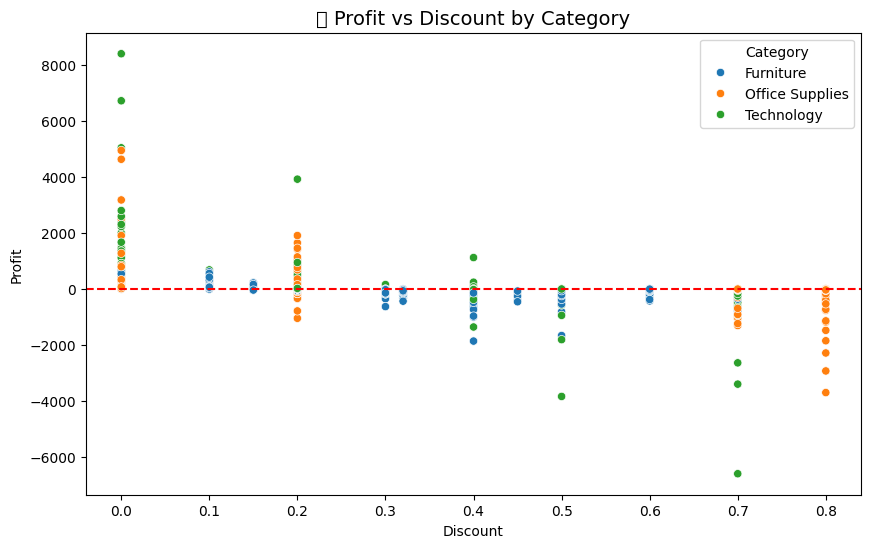

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=orders,
    x="Discount",
    y="Profit",
    hue="Category"
)

plt.title("📉 Profit vs Discount by Category", fontsize=14)

plt.axhline(0, color='red', linestyle='--')

plt.show()

#### Critical Insight

Discounts above ~30–40% are dangerous

You can clearly see:

At 0.5, 0.7, 0.8 → heavy losses
Some losses go as deep as -6000+

#### Category-Level Insight
##### Furniture (Blue)
Most points below zero at higher discounts
Confirms earlier finding:
Furniture = profit problem
##### Office Supplies
Moderate losses at high discount
##### Technology
More resilient, but still suffers at high discount

---
There is a strong negative correlation between discount levels and profitability. Discounts above 30% consistently lead to losses, especially in the Furniture category.

#### Discount Bucketing

In [11]:
# Create discount buckets
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

orders["Discount Bucket"] = pd.cut(orders["Discount"], bins=bins, labels=labels)

# Group by bucket
discount_analysis = orders.groupby("Discount Bucket").agg({
    "Profit": "mean",
    "Sales": "sum"
}).reset_index()

discount_analysis

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19960\1803156813.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = orders.groupby("Discount Bucket").agg({


,Discount Bucket,Profit,Sales
0,0-20%,26.501571,846522.2405
1,20-40%,-78.007422,233856.5258
2,40-60%,-134.624160,71048.2140
3,60-80%,-98.348741,57584.0380
4,80-100%,NaN,0.0000


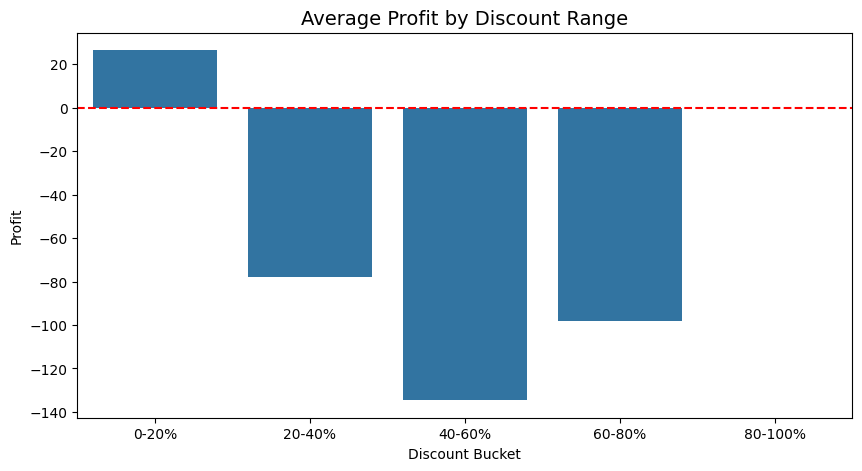

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(data=discount_analysis, x="Discount Bucket", y="Profit")

plt.title("Average Profit by Discount Range", fontsize=14)
plt.axhline(0, color='red', linestyle='--')

plt.show()

### Final Insight
| Discount Range | Avg Profit          |
| -------------- | ------------------- |
| **0–20%**      | +26 (Profitable)  |
| **20–40%**     | -78 (Loss)        |
| **40–60%**     | -134 (Heavy Loss) |
| **60–80%**     | -98 (Loss)        |

##### Critical Business Conclusion
Anything above ~20% discount leads to losses
Orders with discounts exceeding 20% consistently result in negative average profit, with losses peaking in the 40–60% range. This indicates that current discounting strategies are unsustainable and require optimization.


#### Business Recommendation
Cap discounts at 20% and avoid deep discounting unless strategically justified, as higher discounts lead to diminishing returns and increased losses



### Region Analysis
We find:
Which region is performing best/worst

In [14]:
region_analysis = orders.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

region_analysis = region_analysis.sort_values(by="Profit")

region_analysis

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
2,South,391721.9050,46749.4303
1,East,669570.4980,89289.8605
3,West,725457.8245,108418.4489


c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


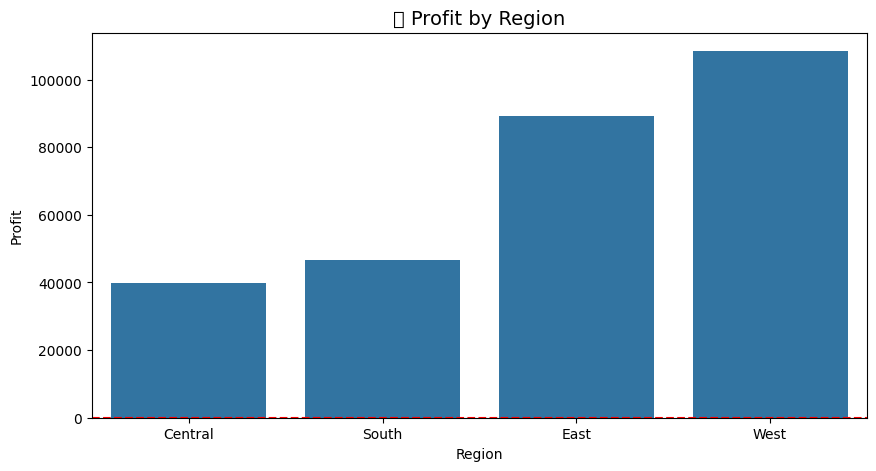

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(data=region_analysis, x="Region", y="Profit")

plt.title("🌍 Profit by Region", fontsize=14)
plt.axhline(0, color='red', linestyle='--')

plt.show()

##### Key Business Insight

Central region is inefficient

Sales ≈ 500K (not low)
Profit ≈ 39K (low)

Means:

High costs OR
High discounts OR
High returns
Despite generating moderate sales, the Central region underperforms in profitability, indicating potential inefficiencies such as excessive discounting or operational costs.

Now we ask:

WHY is Central region weak?

We will validate using:

Discount patterns
Return rates

#### Region vs Discount


In [16]:
region_discount = orders.groupby("Region")["Discount"].mean().reset_index()

region_discount

,Region,Discount
0,Central,0.240353
1,East,0.145874
2,South,0.147253
3,West,0.109335


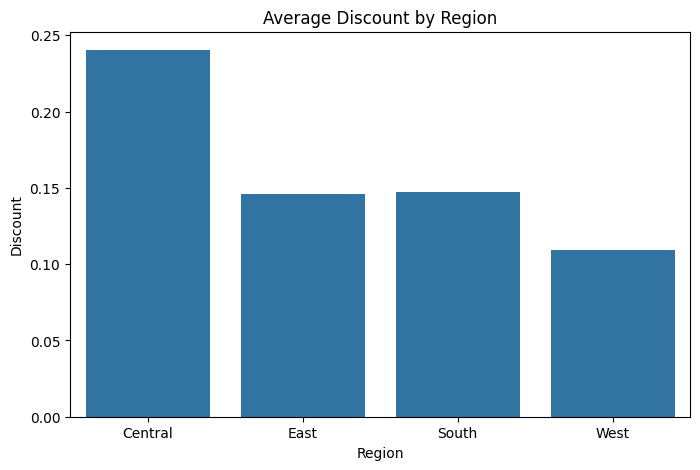

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(data=region_discount, x="Region", y="Discount")

plt.title("Average Discount by Region")
plt.show()

##### Business Conclusion (VERY STRONG)

👉 Central region is giving the highest discounts → causing low profit

👉 West region gives lowest discounts → highest profit



The Central region exhibits the highest average discount (~24%), which directly correlates with its low profitability. In contrast, the West region maintains lower discount levels (~11%) and achieves the highest profit, highlighting the negative impact of aggressive discounting strategies.

#### RETURN ANALYSIS

In [19]:
return_region = orders.groupby("Region")["Returned"].mean().reset_index()

return_region["Return %"] = return_region["Returned"] * 100

return_region

,Region,Returned,Return %
0,Central,0.039604,3.960396
1,East,0.052539,5.253879
2,South,0.042593,4.259259
3,West,0.152982,15.298158


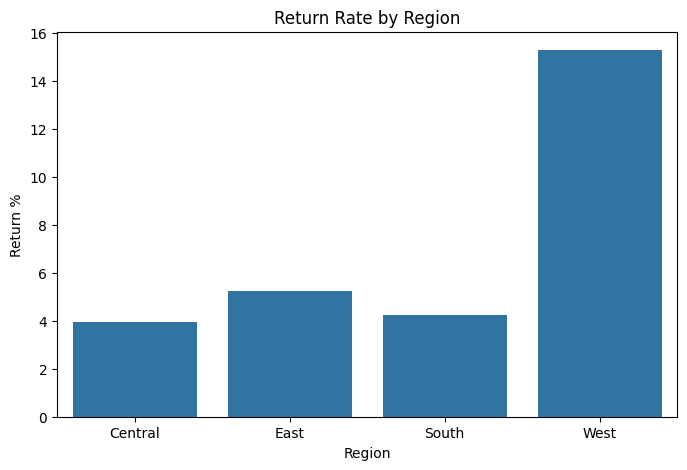

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(data=return_region, x="Region", y="Return %")

plt.title("Return Rate by Region")

plt.show()

In [21]:
return_category = orders.groupby("Category")["Returned"].mean().reset_index()
return_category["Return %"] = return_category["Returned"] * 100

return_category

,Category,Returned,Return %
0,Furniture,0.080737,8.073654
1,Office Supplies,0.078571,7.857143
2,Technology,0.084599,8.459870


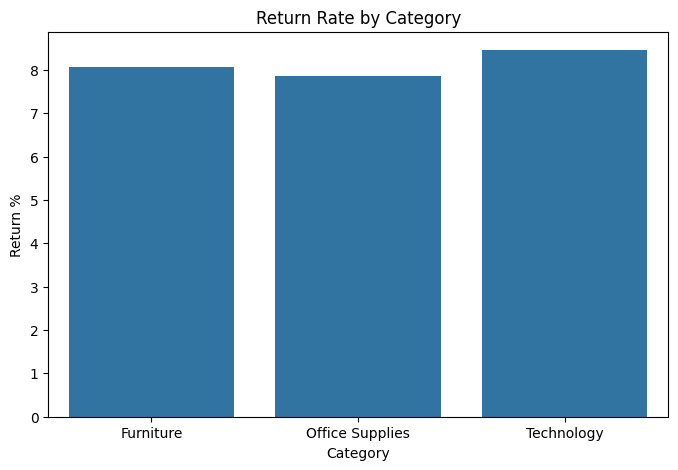

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(data=return_category, x="Category", y="Return %")

plt.title("Return Rate by Category")

plt.show()

##### Finding

- West region has extremely high return rate (~15%)

That’s:

Almost 2–3x higher than other regions


But here’s the twist (VERY IMPORTANT)

Earlier we saw:

West → highest profit
West → lowest discount

- Yet:

West → highest returns


Deep Business Insight

- This suggests:

Returns are NOT driven by discounts

Instead, likely causes:

Product quality issues
Logistics/shipping issues
Customer expectations mismatch


Key Insight

- Returns are NOT category-specific

They are:
- Region-specific problem (West)



1️⃣ Region Insight

👉 “The West region exhibits an abnormally high return rate (~15%), significantly higher than other regions, indicating potential issues in logistics, fulfillment, or customer satisfaction.”

2️⃣ Category Insight

👉 “Return rates are relatively consistent across product categories, suggesting that returns are not driven by product type but rather by regional factors.”


BIG PICTURE (Your Story So Far)

You have now built a complete business narrative:

✅ Profit Problem
Furniture → low profit
Tables → major losses
✅ Root Cause
High discounts (>20%) → losses
✅ Regional Issue
Central → high discount → low profit
✅ New Discovery
West → high returns (not linked to discount)

### Top Products
Now we identify:
👉 Revenue drivers

In [27]:
top_products = orders.groupby("ProductName")["Sales"].sum().reset_index()

top_products = top_products.sort_values(by="Sales", ascending=False).head(10)

top_products

,ProductName,Sales
403,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
443,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


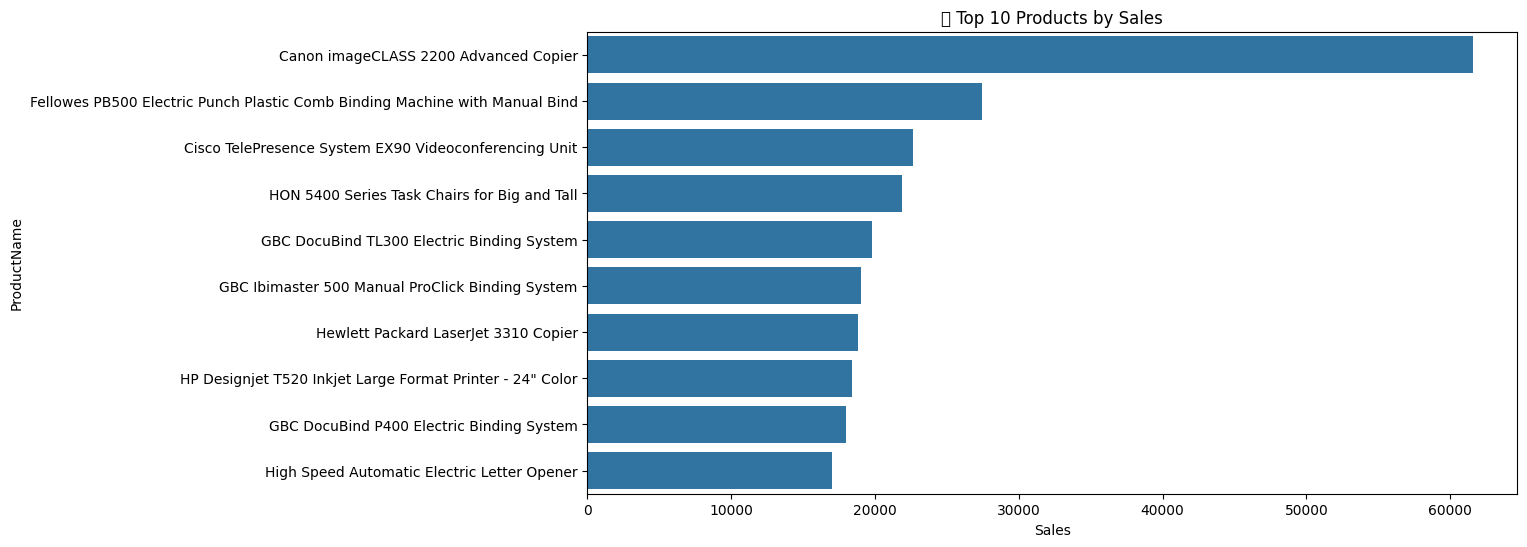

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(data=top_products, y="ProductName", x="Sales")

plt.title("🏆 Top 10 Products by Sales")

plt.show()

🏆 Top Products Analysis (Industry-Level Insight)
📊 Key Observations
🥇 Clear Winner
Canon imageCLASS 2200 Advanced Copier
Sales ≈ 61.6K
🚀 Way ahead of others (almost 2x)
📦 Strong Performers
Fellowes PB500 Binding Machine (~27K)
Cisco TelePresence (~22K)
HON Chairs (~21K)

👉 These are:

High-value items
Likely premium products
🧠 Pattern You Should Notice

👉 Most top products are:

Technology
Office Equipment
High-ticket items
💡 Business Insight

👉 “Top revenue-generating products are predominantly high-value technology and office equipment items, indicating that a small number of premium products contribute significantly to overall revenue.”

🚨 Important Missing Piece (VERY IMPORTANT)

Right now you only looked at Sales

👉 But business cares about:

💰 Profit

### Sales vs Profit

In [30]:
top_products_profit = orders.groupby("ProductName").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

top_products_profit = top_products_profit.sort_values(by="Sales", ascending=False).head(10)

top_products_profit


,ProductName,Sales,Profit
403,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03
443,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03
785,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.979039e-13
685,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
804,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03
682,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03
812,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02


📊 Sales vs Profit — Critical Findings
🏆 True Winners (High Sales + High Profit)
Canon imageCLASS Copier
Sales: ~61K
Profit: ~25K ✅
Fellowes PB500
HP LaserJet
HP Designjet

👉 These are:

High-value + high-margin products
Ideal for business focus
🚨 Dangerous Products (High Sales but Loss ❌)
❌ Cisco TelePresence
Sales: ~22K
Profit: -1.8K
❌ GBC DocuBind P400
Profit: -1.8K
❌ Letter Opener
Profit: negative
⚠️ Zero-Profit Product (Very Interesting)
⚠️ HON Chairs
Sales: ~21K
Profit ≈ 0

👉 Means:

Selling at cost OR
Heavy discounting
🔥 BIGGEST BUSINESS INSIGHT

👉 High revenue products are not always profitable

💡 Industry-Level Statement (USE THIS)

👉 “Several top-selling products, including Cisco TelePresence and GBC binding systems, are operating at a loss despite strong sales performance, indicating inefficiencies in pricing or discount strategies.”

🧠 Deep Insight (Advanced Level)

You now have:

✅ Profit Drivers
Canon Copier
HP Products
❌ Loss Drivers
Cisco system
Binding systems

👉 This helps in:

Pricing decisions
Inventory strategy
🚀 FINAL EDA SUMMARY (Your Story)

You’ve built a complete business analysis:

💸 Profit Leakage
Furniture → weak
Tables → worst
📉 Root Cause
Discounts >20% → losses
🌍 Region Issue
Central → high discount → low profit
🔁 Returns Insight
West → very high returns (~15%)
🏆 Product Insight
Some top products → loss-making